In [1]:
import numpy as np 
import keras

# Fit model to data

## Preprocessing

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('../dataset/open-meteo_historical.csv')
df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²)
0,2023-01-01T00:00,18.3,88,16.2,17.5,0.0,100,70,100,0,51.4,3.2,48.1,12.3,368.2
1,2023-01-01T01:00,19.0,84,16.3,18.3,0.0,99,52,99,0,79.1,0.0,79.1,0.0,610.0
2,2023-01-01T02:00,20.1,80,16.5,19.4,0.0,100,83,100,0,198.7,41.5,157.2,74.0,794.2
3,2023-01-01T03:00,20.0,81,16.7,19.5,0.0,100,74,100,0,125.0,0.0,125.0,0.0,908.4
4,2023-01-01T04:00,19.7,83,16.7,19.3,0.1,100,96,100,0,117.4,3.0,114.4,4.5,944.8


In [4]:
df.set_index('time', inplace=True)

df.head()

,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²)
time,,,,,,,,,,,,,,
2023-01-01T00:00,18.3,88,16.2,17.5,0.0,100,70,100,0,51.4,3.2,48.1,12.3,368.2
2023-01-01T01:00,19.0,84,16.3,18.3,0.0,99,52,99,0,79.1,0.0,79.1,0.0,610.0
2023-01-01T02:00,20.1,80,16.5,19.4,0.0,100,83,100,0,198.7,41.5,157.2,74.0,794.2
2023-01-01T03:00,20.0,81,16.7,19.5,0.0,100,74,100,0,125.0,0.0,125.0,0.0,908.4
2023-01-01T04:00,19.7,83,16.7,19.3,0.1,100,96,100,0,117.4,3.0,114.4,4.5,944.8


In [5]:
print(df.shape)

(8760, 14)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8760 entries, 2023-01-01T00:00 to 2023-12-31T23:00
Data columns (total 14 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   temperature_2m (°C)                      8760 non-null   float64
 1   relative_humidity_2m (%)                 8760 non-null   int64  
 2   dew_point_2m (°C)                        8760 non-null   float64
 3   apparent_temperature (°C)                8760 non-null   float64
 4   rain (mm)                                8760 non-null   float64
 5   cloud_cover (%)                          8760 non-null   int64  
 6   cloud_cover_low (%)                      8760 non-null   int64  
 7   cloud_cover_mid (%)                      8760 non-null   int64  
 8   cloud_cover_high (%)                     8760 non-null   int64  
 9   shortwave_radiation_instant (W/m²)       8760 non-null   float64
 10  direct_radiation_instant (

In [7]:
data_features = df[['temperature_2m (°C)', 'relative_humidity_2m (%)', 'dew_point_2m (°C)',
                    'apparent_temperature (°C)', 'rain (mm)', 'cloud_cover (%)', 'cloud_cover_low (%)',
                    'cloud_cover_mid (%)', 'cloud_cover_high (%)', 'shortwave_radiation_instant (W/m²)', 
                    'diffuse_radiation_instant (W/m²)', 'direct_radiation_instant (W/m²)',
                    'direct_normal_irradiance_instant (W/m²)', 'terrestrial_radiation_instant (W/m²)']].values
data_target = df['diffuse_radiation_instant (W/m²)'].values

In [8]:
print(len(data_features))

8760


In [9]:
look_back = 24 #menggunakan timestamp 24
n_ahead = 1 # predict 1 jam berikutnya

x_seq = []
y_seq = []

for i in range(len(data_features) - look_back - n_ahead + 1):
    print("i: ", i)
    print("untuk x seq: ", i + look_back)
    print("i + lookback: ", i + look_back)
    print("i + look_back + n_ahead: ", i + look_back + n_ahead)
    x_seq.append(data_features[i : (i + look_back)]) # mengambil value 24 jam sebelum
    y_seq.append(data_target[(i + look_back) : (i + look_back + n_ahead)]) #mengambil value 1 jam berikutnya

x_seq, y_seq = np.array(x_seq), np.array(y_seq)

i:  0
untuk x seq:  24
i + lookback:  24
i + look_back + n_ahead:  25
i:  1
untuk x seq:  25
i + lookback:  25
i + look_back + n_ahead:  26
i:  2
untuk x seq:  26
i + lookback:  26
i + look_back + n_ahead:  27
i:  3
untuk x seq:  27
i + lookback:  27
i + look_back + n_ahead:  28
i:  4
untuk x seq:  28
i + lookback:  28
i + look_back + n_ahead:  29
i:  5
untuk x seq:  29
i + lookback:  29
i + look_back + n_ahead:  30
i:  6
untuk x seq:  30
i + lookback:  30
i + look_back + n_ahead:  31
i:  7
untuk x seq:  31
i + lookback:  31
i + look_back + n_ahead:  32
i:  8
untuk x seq:  32
i + lookback:  32
i + look_back + n_ahead:  33
i:  9
untuk x seq:  33
i + lookback:  33
i + look_back + n_ahead:  34
i:  10
untuk x seq:  34
i + lookback:  34
i + look_back + n_ahead:  35
i:  11
untuk x seq:  35
i + lookback:  35
i + look_back + n_ahead:  36
i:  12
untuk x seq:  36
i + lookback:  36
i + look_back + n_ahead:  37
i:  13
untuk x seq:  37
i + lookback:  37
i + look_back + n_ahead:  38
i:  14
untuk x s

In [10]:
print(x_seq.shape)
print(y_seq.shape)

(8736, 24, 14)
(8736, 1)


In [11]:
split_point = int(len(x_seq) * 0.8) # 80% for training and 20% for testing

x_train, x_test = x_seq[:split_point], x_seq[split_point:]
y_train, y_test = y_seq[:split_point], y_seq[split_point:]

#flatten the y

y_train = y_train.flatten()
y_test = y_test.flatten()

print(f'x_train shape: {x_train.shape}, x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')

x_train shape: (6988, 24, 14), x_test shape: (1748, 24, 14)
y_train shape: (6988,), y_test shape: (1748,)


In [12]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_x = RobustScaler()
scaler_y = RobustScaler()

#fit dan transform the training data
#kalau mau fit transform, data harus 2 dimensi. untuk x, kembalikan ke 3 dimensi. untuk y, kembalikan 1 dimensi
x_train_scaled = scaler_x.fit_transform(x_train.reshape(-1, 14)).reshape(x_train.shape[0], x_train.shape[1], 14) 
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, n_ahead)).reshape(-1, n_ahead, 1)
# y_train_scaled = y_train_scaled.flatten()

# tranform the testing data
x_test_scaled = scaler_x.fit_transform(x_test.reshape(-1, 14)).reshape(x_test.shape[0], x_test.shape[1], 14)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, n_ahead)).reshape(-1, n_ahead, 1)
# y_test_scaled = y_test_scaled.flatten()

# # Reshape X_train and X_test to 3D for LSTM input (samples, time steps, features)
# X_train_scaled = X_train.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
# X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Check the shapes after standardization
print(f'X_train_scaled shape: {x_train_scaled.shape}, X_test_scaled shape: {x_test_scaled.shape}')
print(f'y_train_scaled shape: {y_train_scaled.shape}, y_test_scaled shape: {y_test_scaled.shape}')

X_train_scaled shape: (6988, 24, 14), X_test_scaled shape: (1748, 24, 14)
y_train_scaled shape: (6988, 1, 1), y_test_scaled shape: (1748, 1, 1)


# Hyper parameters dan model configuration

In [13]:
keras.backend.clear_session()

#hidden neuron in each layer dari encoder dan decoder

layers = [35, 35]

learning_rate = 0.01
decay = 0 #learning rate decay

# optimizer "sgd" (stochastic gradient descent)
optimizer = keras.optimizers.Adam(learning_rate=learning_rate, decay=decay)

num_input_features = 14 #dimensi input pada tiap time step. kita pake 14 feature
num_output_features = 1 #dimensi output pada tiap timestep

loss = "mse"

lambda_regulariser = 0.000001 #ga digunakan kalau regulariser none
regulariser = None #possible regulariser: keras.regularizers.l2 (lambda_regularizer)

batch_size = 512
steps_per_epoch = 200 #batch size * step per epoch = total number dari training examples
epochs = 15

input_sequence_length = 24 #length sequence yang digunakan encoder. disiini 24 jam
target_sequence_length = 1 #length dari sequence predicted decoder. disini predict 1 jam berikutnya
num_steps_to_predict = 1  #length yang digunakan ketika testing model. disini pake predict 1 jam



/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


# Create model

## Create encoder

In [14]:
# Define an input sequence.
encoder_inputs = keras.layers.Input(shape=(None, num_input_features))

#membuat list RNN cells, digabung menjadi single layer

encoder_cells = []
for hidden_neurons in layers:
    encoder_cells.append(keras.layers.GRUCell(hidden_neurons,
                                              kernel_regularizer=regulariser,
                                              recurrent_regularizer=regulariser,
                                              bias_regularizer=regulariser))

encoder = keras.layers.RNN(encoder_cells, return_state=True)

encoder_outputs_and_states = encoder(encoder_inputs)

# Discard encoder outputs and only keep the states.
# The outputs are of no interest to us, the encoder's
# job is to create a state describing the input sequence.
encoder_states = encoder_outputs_and_states[1:]

## Create Decoder

In [15]:
# The decoder input will be set to zero (see random_sine function of the utils module).
# Do not worry about the input size being 1, I will explain that in the next cell.
decoder_inputs = keras.layers.Input(shape=(None, 1))

decoder_cells = []
for hidden_neurons in layers:
    decoder_cells.append(keras.layers.GRUCell(hidden_neurons,
                                              kernel_regularizer=regulariser,
                                              recurrent_regularizer=regulariser,
                                              bias_regularizer=regulariser))

decoder = keras.layers.RNN(decoder_cells, return_sequences=True, return_state=True)

# Set the initial state of the decoder to be the ouput state of the encoder.
# This is the fundamental part of the encoder-decoder.
decoder_outputs_and_states = decoder(decoder_inputs, initial_state=encoder_states)

# Only select the output of the decoder (not the states)
decoder_outputs = decoder_outputs_and_states[0]

# Apply a dense layer with linear activation to set output to correct dimension
# and scale (tanh is default activation for GRU in Keras, our output sine function can be larger then 1)
decoder_dense = keras.layers.Dense(num_output_features,
                                   activation='linear',
                                   kernel_regularizer=regulariser,
                                   bias_regularizer=regulariser)

decoder_outputs = decoder_dense(decoder_outputs)

## Create model and compile

Train model punya 2 input: encoder_inputs dan decoder_inputs

encoder_inputs = input series
decoder_inputs = di set 0 awalnya

In [16]:
# Create a model using the functional API provided by Keras.
# The functional API is great, it gives an amazing amount of freedom in architecture of your NN.
# A read worth your time: https://keras.io/getting-started/functional-api-guide/ 
model = keras.models.Model(inputs=[encoder_inputs, decoder_inputs], outputs=decoder_outputs)
model.compile(optimizer=optimizer, loss=loss)

## Fit model to data

In [17]:
from util import fitModel, plot_prediction

In [18]:
train_data_generator = fitModel(batch_size, steps_per_epoch, 
                                x_train_scaled, y_train_scaled)

model.fit(train_data_generator, steps_per_epoch=steps_per_epoch, epochs=epochs)

Epoch 1/15


/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_4']. Received: the structure of inputs=('*', '*')
  warnings.warn(


200/200 ━━━━━━━━━━━━━━━━━━━━ 32s 153ms/step - loss: 0.0893
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 204ms/step - loss: 0.0222
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 43s 215ms/step - loss: 0.0152
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 243ms/step - loss: 0.0081
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 228ms/step - loss: 0.0039
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 227ms/step - loss: 0.0024
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 223ms/step - loss: 0.0011
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 224ms/step - loss: 7.9675e-04
Epoch 9/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 234ms/step - loss: 6.3836e-04
Epoch 10/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 232ms/step - loss: 7.5327e-04
Epoch 11/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 233ms/step - loss: 4.0163e-04
Epoch 12/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 234ms/step - loss: 4.2391e-04
Epoch 13/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 236ms/step - loss: 4.9862e-04
Epoch 14/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 226ms/step - loss: 3.8647e-0

# Create Prediction Models

In [19]:
encoder_predict_model = keras.models.Model(encoder_inputs,
                                           encoder_states)

decoder_states_inputs = []

# Read layers backwards to fit the format of initial_state
# For some reason, the states of the model are order backwards (state of the first layer at the end of the list)
# If instead of a GRU you were using an LSTM Cell, you would have to append two Input tensors since the LSTM has 2 states.
for hidden_neurons in layers[::-1]:
    # One state for GRU
    decoder_states_inputs.append(keras.layers.Input(shape=(hidden_neurons,)))

decoder_outputs_and_states = decoder(
    decoder_inputs, initial_state=decoder_states_inputs)

decoder_outputs = decoder_outputs_and_states[0]
decoder_states = decoder_outputs_and_states[1:]

decoder_outputs = decoder_dense(decoder_outputs)

# decoder_predict_model = keras.models.Model(
#         [decoder_inputs] + decoder_states_inputs,
#         [decoder_outputs] + decoder_states)

decoder_predict_model = keras.models.Model(
    inputs=[decoder_inputs] + decoder_states_inputs,
    outputs=[decoder_outputs] + [state for state in decoder_outputs_and_states[1:]]
)

In [20]:
# Let's define a small function that predicts based on the trained encoder and decoder models

def predict(x, encoder_predict_model, decoder_predict_model, num_steps_to_predict):
    """Predict time series with encoder-decoder.
    
    Uses the encoder and decoder models previously trained to predict the next
    num_steps_to_predict values of the time series.
    
    Arguments
    ---------
    x: input time series of shape (batch_size, input_sequence_length, input_dimension).
    encoder_predict_model: The Keras encoder model.
    decoder_predict_model: The Keras decoder model.
    num_steps_to_predict: The number of steps in the future to predict
    
    Returns
    -------
    y_predicted: output time series for shape (batch_size, target_sequence_length,
        ouput_dimension)
    """
    y_predicted = []

    # Encode the values as a state vector
    states = encoder_predict_model.predict(x)

    # The states must be a list
    if not isinstance(states, list):
        states = [states]

    # Generate first value of the decoder input sequence
    decoder_input = np.zeros((x.shape[0], 1, 1))


    for _ in range(num_steps_to_predict):
        outputs_and_states = decoder_predict_model.predict(
        [decoder_input] + states, batch_size=batch_size)
        output = outputs_and_states[0]
        states = outputs_and_states[1:]

        # add predicted value
        y_predicted.append(output)

    return np.concatenate(y_predicted, axis=1)
    

In [21]:
test_data_generator = fitModel(batch_size, steps_per_epoch, 
                                x_test_scaled, y_test_scaled)

(x_test_scaled2, _), y_test_scaled2 = next(test_data_generator)

In [22]:
print(x_test_scaled2.shape)
print(y_test_scaled2.shape)

(1748, 24, 14)
(1748, 1, 1)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_4', 'keras_tensor_9', 'keras_tensor_10']. Received: the structure of inputs=('*', ('*', '*'))
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
(1748, 1, 1)


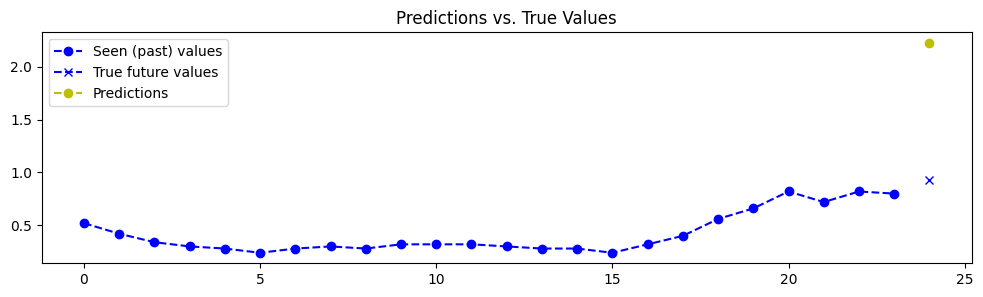

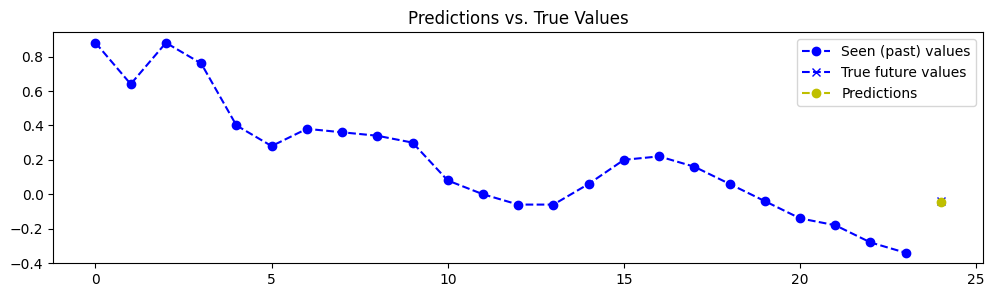

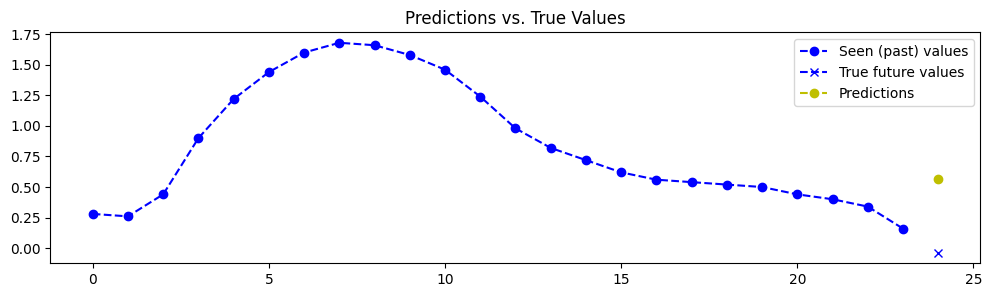

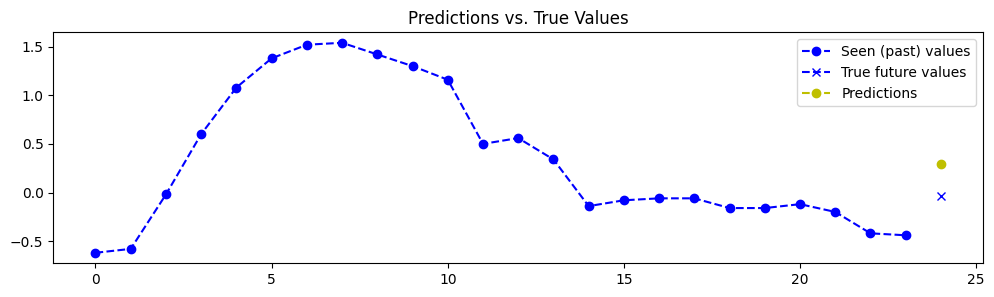

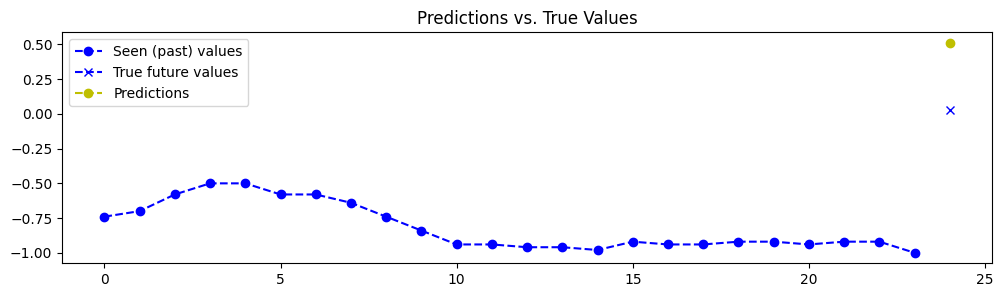

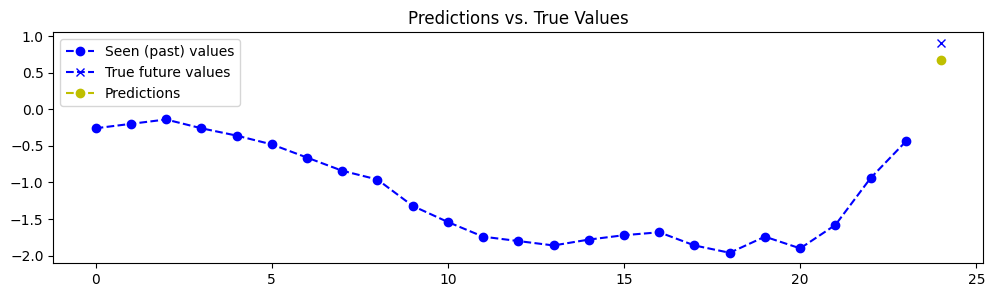

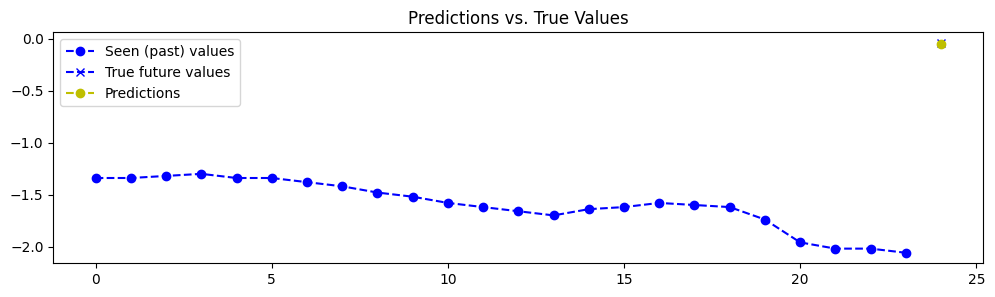

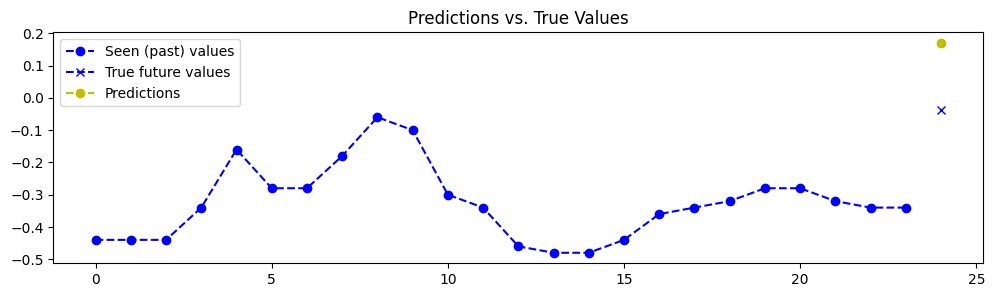

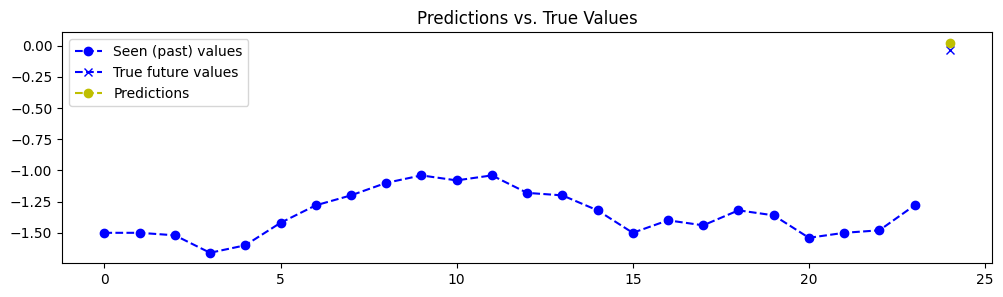

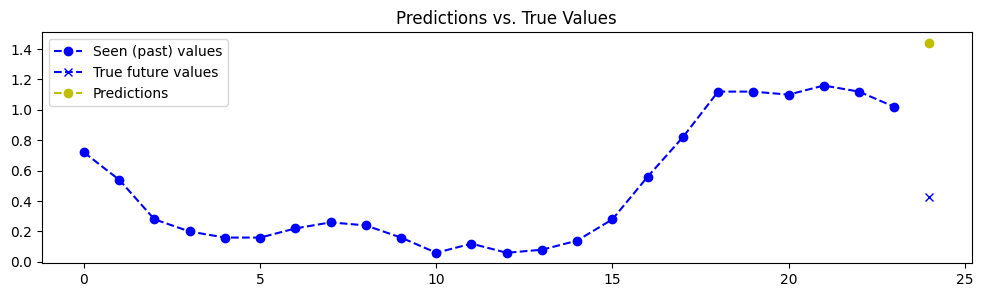

In [23]:
y_test_predicted = predict(x_test_scaled2, encoder_predict_model, decoder_predict_model, num_steps_to_predict)

print(y_test_predicted.shape)

# Select 10 random examples to plot
indices = np.random.choice(range(x_test.shape[0]), replace=False, size=10)


for index in indices:
    plot_prediction(x_test_scaled2[index, :, :], y_test_scaled2[index, :, :], y_test_predicted[index, :, :])
    